# Logistic Regression (logit) for Binary Dependent Variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

In [2]:
# Uncomment lines below to create random data for testing purposes
# n = 1000
# data = pd.DataFrame()
# data['gender'] = np.random.choice(['Male', 'Female'], size=n)
# data['age'] = np.random.randint(18, 65, size=n)
# data['visits'] = np.random.randint(0, 10, size=n)
# data['past_purchases'] = np.random.randint(0, 10, size=n)
# data['purchased'] = np.random.randint(0, 2, size=n)

In [3]:
df = pd.read_csv('../../../datasets/logit_data.csv')
df.columns
df.head()

,purchased,gender,age,visits,past_purchases
0,0,M,23,3,0
1,0,M,24,3,0
2,0,M,18,1,1
3,0,F,26,4,1
4,0,M,19,2,1


In [4]:
X = df[['gender', 'age', 'visits', 'past_purchases']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
X = sm.add_constant(X)
y = df['purchased']
X.head()

,const,age,visits,past_purchases,gender_M
0,1.0,23,3,0,1
1,1.0,24,3,0,1
2,1.0,18,1,1,1
3,1.0,26,4,1,0
4,1.0,19,2,1,1


In [5]:
model = sm.Logit(y, X)
result = model.fit()
result.summary2()

Optimization terminated successfully.
         Current function value: 0.536389
         Iterations 6


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Logit
================================================================
Model:              Logit            Method:           MLE      
Dependent Variable: purchased        Pseudo R-squared: 0.225    
Date:               2026-03-09 13:44 AIC:              63.6389  
No. Observations:   50               BIC:              73.1990  
Df Model:           4                Log-Likelihood:   -26.819  
Df Residuals:       45               LL-Null:          -34.617  
Converged:          1.0000           LLR p-value:      0.0036124
No. Iterations:     6.0000           Scale:            1.0000   
----------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
----------------------------------------------------------------
const            -1.2181   1.5258 -0.7984 0.4247 -4.2085  1.7723
age               0.0415   0.0275  1.5066 0.1319 -0.0125  0.0954
visits           -0.1541   0.3253 -0.4738 0.6356 -0.7916  0.4834
past_purchases    0.7168   0.5567  1.2875 0.1979 -0.3744  1.8080
gender_M         -1.4647   0.7113 -2.0592 0.0395 -2.8589 -0.0706
================================================================

"""

In [6]:
y_probabilities = result.predict(X)
y_predictions = np.round(y_probabilities).astype(int)

print("Predicted probabilities:")
print(y_probabilities.head())

print("Predicted classes:")
print(y_predictions[:5])

Predicted probabilities:
0    0.100492
1    0.104302
2    0.201974
3    0.490012
4    0.184425
dtype: float64
Predicted classes:
0    0
1    0
2    0
3    0
4    0
dtype: int64


In [7]:
coefficients = result.params
odds_ratios = np.exp(coefficients)

print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
const             0.295795
age               1.042322
visits            0.857184
past_purchases    2.047895
gender_M          0.231137
dtype: float64


In [8]:
marginal_effects = result.get_margeff(at='mean')
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:              purchased
Method:                          dydx
At:                              mean
                    dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
age                0.0103      0.007      1.509      0.131      -0.003       0.024
visits            -0.0383      0.081     -0.474      0.636      -0.197       0.120
past_purchases     0.1780      0.138      1.291      0.197      -0.092       0.448
gender_M          -0.3638      0.176     -2.065      0.039      -0.709      -0.018


In [9]:
elasticities = result.get_margeff(at='mean', method='eyex')
print(elasticities.summary())

        Logit Marginal Effects       
Dep. Variable:              purchased
Method:                          eyex
At:                              mean
               d(lny)/d(lnx)    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
age                   0.6702      0.454      1.476      0.140      -0.219       1.560
visits               -0.1727      0.366     -0.472      0.637      -0.889       0.544
past_purchases        0.5137      0.402      1.278      0.201      -0.274       1.301
gender_M             -0.3768      0.191     -1.978      0.048      -0.750      -0.003


In [10]:
cm = confusion_matrix(y, y_predictions)
print(cm)

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

[[19  5]
 [ 7 19]]


In [11]:
accuracy = accuracy_score(y, y_predictions)
print("Accuracy:", accuracy)

Accuracy: 0.76


In [12]:
report = classification_report(y, y_predictions)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        24
           1       0.79      0.73      0.76        26

    accuracy                           0.76        50
   macro avg       0.76      0.76      0.76        50
weighted avg       0.76      0.76      0.76        50



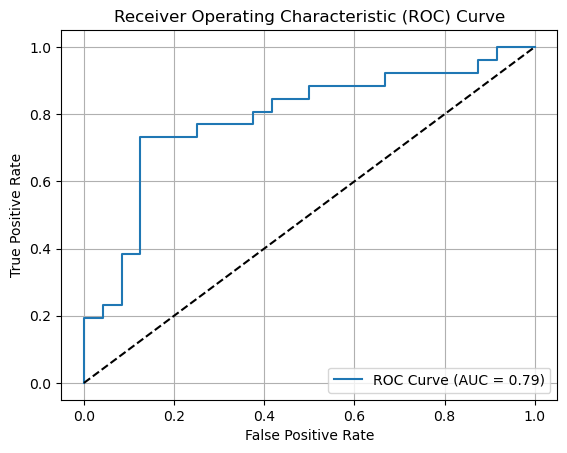

AUC Score: 0.788


In [13]:
y_true = y
y_scores = y_probabilities

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_true, y_scores):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc_score(y_true, y_scores):.3f}")

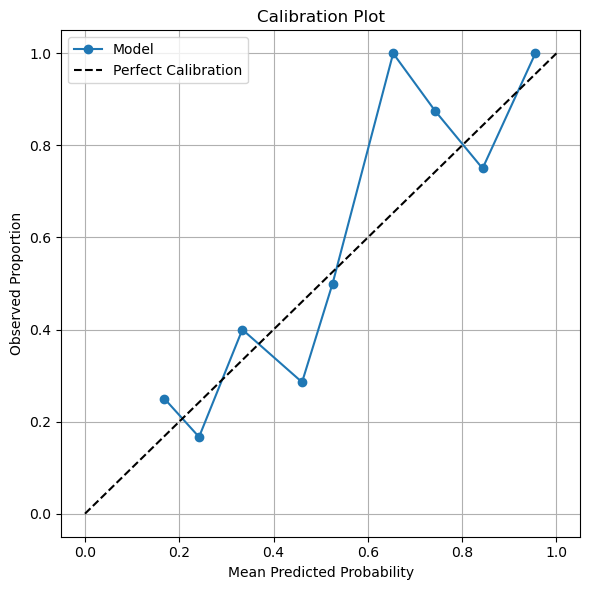

In [14]:
prob_true, prob_pred = calibration_curve(y, y_probabilities, n_bins=10, strategy='uniform')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Proportion')
plt.title('Calibration Plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

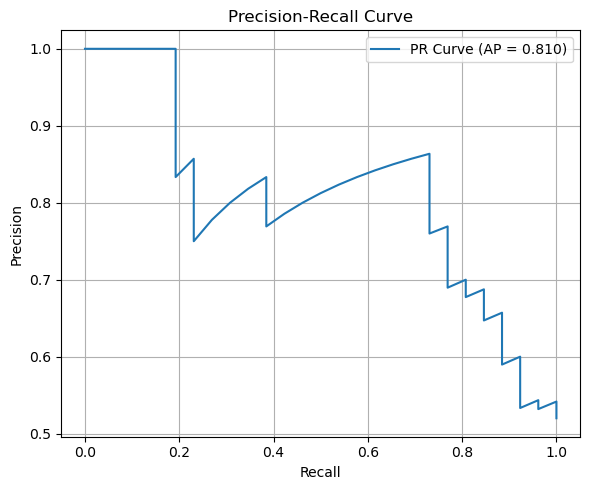

In [15]:
precision, recall, thresholds = precision_recall_curve(y, y_probabilities)
ap = average_precision_score(y, y_probabilities)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

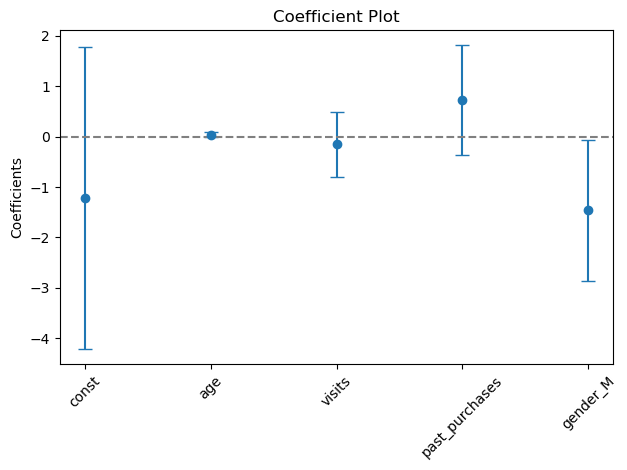

In [16]:
coefficients = result.params
conf_int = result.conf_int()

plt.errorbar(
    coefficients.index,
    coefficients,
    yerr=(coefficients - conf_int[0], conf_int[1] - coefficients),
    fmt='o',
    capsize=5
)
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('Coefficients')
plt.title('Coefficient Plot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

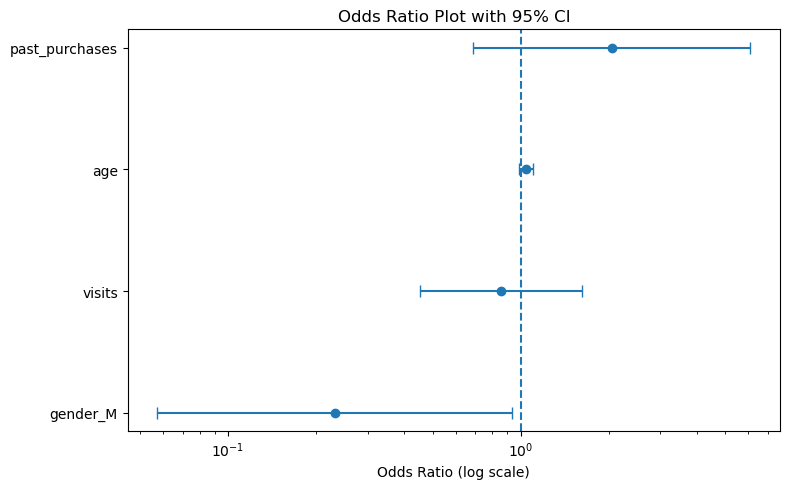

In [17]:
odds_ratios = np.exp(result.params)
conf = result.conf_int()
lower = np.exp(conf[0])
upper = np.exp(conf[1])

or_df = pd.DataFrame({
    'term': odds_ratios.index,
    'odds_ratio': odds_ratios.values,
    'lower': lower.values,
    'upper': upper.values
})

or_df = or_df[or_df['term'] != 'const'].sort_values('odds_ratio')

lower_err = or_df['odds_ratio'] - or_df['lower']
upper_err = or_df['upper'] - or_df['odds_ratio']

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=or_df['odds_ratio'],
    y=or_df['term'],
    xerr=[lower_err, upper_err],
    fmt='o',
    capsize=4
)
plt.axvline(1, linestyle='--')
plt.xscale('log')
plt.xlabel('Odds Ratio (log scale)')
plt.ylabel('')
plt.title('Odds Ratio Plot with 95% CI')
plt.tight_layout()
plt.show()

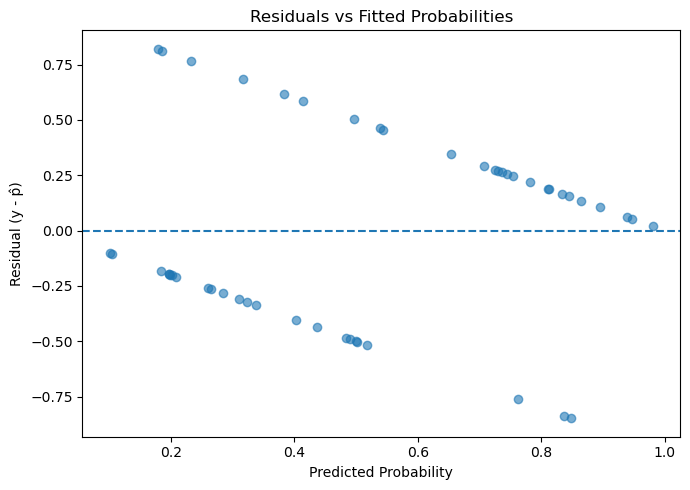

In [18]:
residuals = y - y_probabilities

plt.figure(figsize=(7, 5))
plt.scatter(y_probabilities, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Residual (y - p̂)')
plt.title('Residuals vs Fitted Probabilities')
plt.tight_layout()
plt.show()

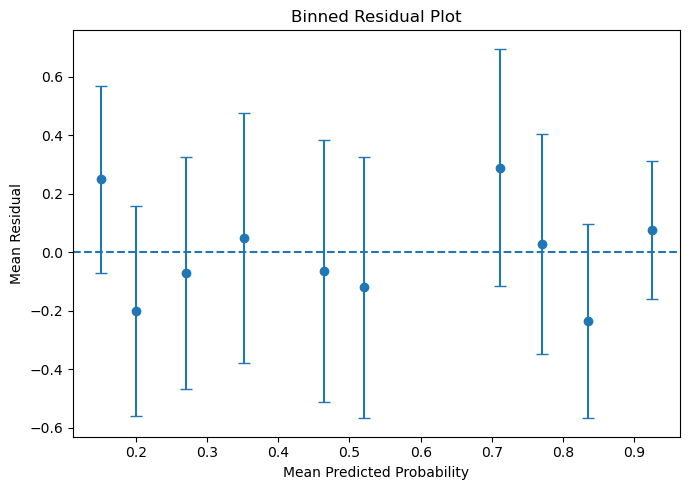

In [19]:
plot_df = pd.DataFrame({
    'y_probabilities': y_probabilities,
    'residuals': y - y_probabilities
}).sort_values('y_probabilities')

plot_df['bin'] = pd.qcut(plot_df['y_probabilities'], q=10, duplicates='drop')

binned = plot_df.groupby('bin', observed=False).agg(
    mean_pred=('y_probabilities', 'mean'),
    mean_resid=('residuals', 'mean'),
    n=('residuals', 'size')
).reset_index(drop=True)

binned['se'] = np.sqrt((binned['mean_pred'] * (1 - binned['mean_pred'])) / binned['n'])

plt.figure(figsize=(7, 5))
plt.errorbar(
    binned['mean_pred'],
    binned['mean_resid'],
    yerr=2 * binned['se'],
    fmt='o',
    capsize=4
)
plt.axhline(0, linestyle='--')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Mean Residual')
plt.title('Binned Residual Plot')
plt.tight_layout()
plt.show()

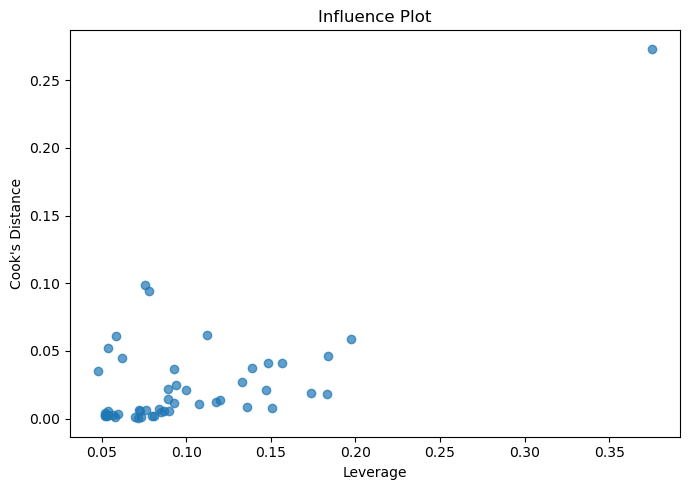

In [20]:
influence = result.get_influence()
leverage = influence.hat_matrix_diag
cooks_distance = influence.cooks_distance[0]

plt.figure(figsize=(7, 5))
plt.scatter(leverage, cooks_distance, alpha=0.7)
plt.xlabel('Leverage')
plt.ylabel("Cook's Distance")
plt.title('Influence Plot')
plt.tight_layout()
plt.show()

In [21]:
influence = result.get_influence()

influence_df = pd.DataFrame({
    'leverage': influence.hat_matrix_diag,
    'cooks_distance': influence.cooks_distance[0],
    'standardized_residuals': influence.resid_studentized
})

print(influence_df.sort_values('cooks_distance', ascending=False).head(10))

    leverage  cooks_distance  standardized_residuals
46  0.375484        0.273199                1.507304
16  0.075771        0.099022               -2.457480
27  0.078136        0.094472               -2.360720
14  0.112499        0.061685                1.559856
11  0.058591        0.060947                2.212761
3   0.197350        0.058866               -1.094107
9   0.053784        0.052513                2.149249
10  0.184067        0.046482                1.015001
29  0.061992        0.045066               -1.846480
8   0.156636        0.041340               -1.054954


In [22]:
prediction_data = pd.DataFrame({
    'gender': ['Male', 'Female', 'Male'],
    'age': [30, 40, 50],
    'visits': [5, 8, 2],
    'past_purchases': [2, 6, 0]
})

prediction_data = pd.get_dummies(prediction_data, drop_first=True, dtype=int)
prediction_data = sm.add_constant(prediction_data)
prediction_data = prediction_data.reindex(columns=X.columns, fill_value=0)

prediction_probabilities = result.predict(prediction_data)
prediction_classes = np.round(prediction_probabilities).astype(int)

print("Predictions:", prediction_classes)
print("Probabilities:", prediction_probabilities)

Predictions: 0    1
1    1
2    1
dtype: int64
Probabilities: 0    0.665645
1    0.970915
2    0.633268
dtype: float64


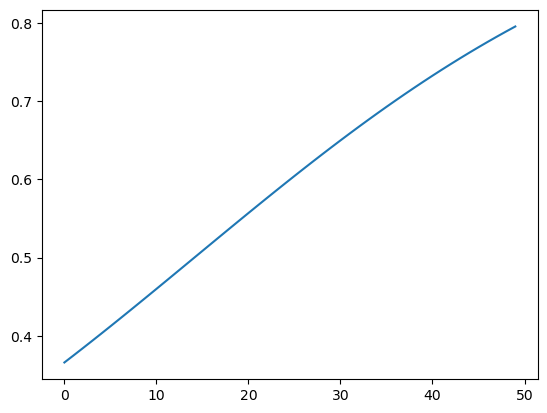

In [26]:
yhat_probabilities = result.predict(sim_df)
yhat = np.round(yhat_probabilities).astype(int)

plt.plot(yhat_probabilities)

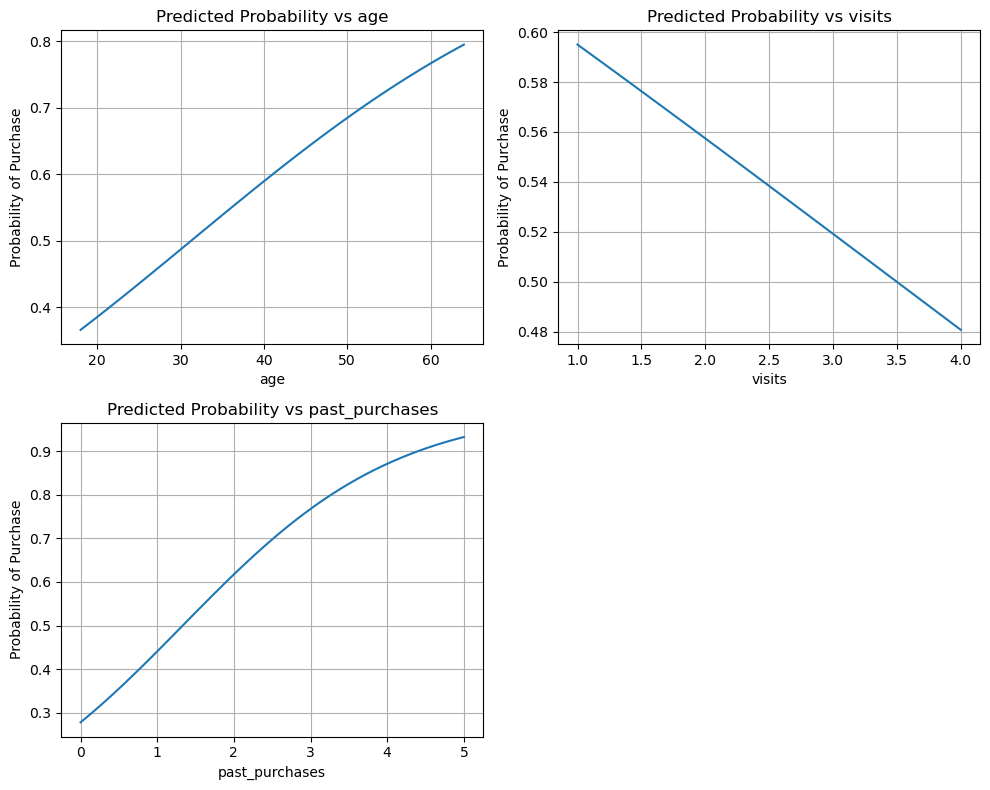

In [23]:
plot_dict = {
    'age': np.linspace(df['age'].min(), df['age'].max(), 100),
    'visits': np.linspace(df['visits'].min(), df['visits'].max(), 100),
    'past_purchases': np.linspace(df['past_purchases'].min(), df['past_purchases'].max(), 100)
}

num_rows = (len(plot_dict) + 1) // 2
fig, axs = plt.subplots(num_rows, 2, figsize=(10, 4 * num_rows))

if num_rows > 1:
    axs = axs.flatten()
else:
    axs = np.array(axs).flatten()

base_row = X.mean().copy()

for i, column in enumerate(plot_dict):
    plot_X = pd.DataFrame([base_row] * len(plot_dict[column]))
    plot_X[column] = plot_dict[column]
    yhat_plot = result.predict(plot_X)

    axs[i].plot(plot_X[column], yhat_plot)
    axs[i].set_xlabel(column)
    axs[i].set_ylabel('Probability of Purchase')
    axs[i].set_title(f'Predicted Probability vs {column}')
    axs[i].grid(True)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

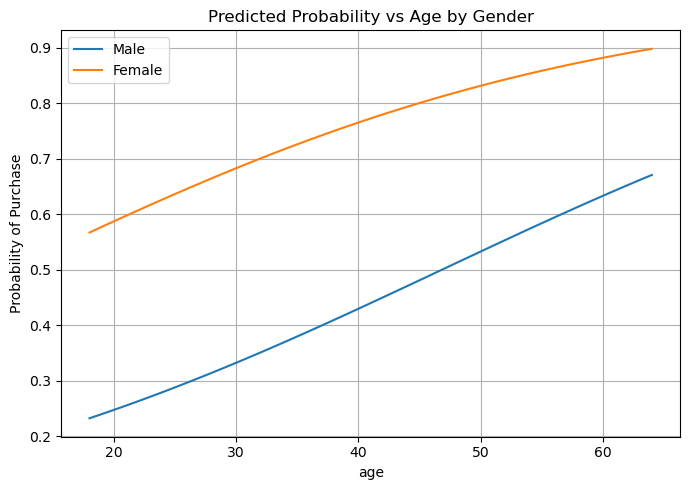

In [24]:
age_span = np.linspace(df['age'].min(), df['age'].max(), 100)

male_df = pd.DataFrame([X.mean().copy()] * len(age_span))
female_df = pd.DataFrame([X.mean().copy()] * len(age_span))

male_df['age'] = age_span
female_df['age'] = age_span

if 'gender_M' in X.columns:
    male_df['gender_M'] = 1
    female_df['gender_M'] = 0

male_probs = result.predict(male_df)
female_probs = result.predict(female_df)

plt.figure(figsize=(7, 5))
plt.plot(age_span, male_probs, label='Male')
plt.plot(age_span, female_probs, label='Female')
plt.xlabel('age')
plt.ylabel('Probability of Purchase')
plt.title('Predicted Probability vs Age by Gender')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
mean_age = X['age'].mean()
mean_visits = X['visits'].mean()
mean_past_purchases = X['past_purchases'].mean()
mean_gender = X['gender_M'].mean()
n = len(X)

age_span = np.linspace(X['age'].min(), X['age'].max(), len(X))
visits_span = np.linspace(X['visits'].min(), X['visits'].max(), len(X))
past_purchases_span = np.linspace(X['past_purchases'].min(), X['past_purchases'].max(), len(X))
gender_M_span = np.linspace(X['gender_M'].min(), X['gender_M'].max(), len(X))

sim_df = pd.DataFrame({
    'const': np.full(n, 1),
    'age': age_span,
    'visits': np.full(n, mean_visits),
    'past_purchases': np.full(n, mean_past_purchases),
    'gender_M': np.full(n, mean_gender)
})

sim_df.head()

,const,age,visits,past_purchases,gender_M
0,1,18.000000,2.44,1.56,0.56
1,1,18.938776,2.44,1.56,0.56
2,1,19.877551,2.44,1.56,0.56
3,1,20.816327,2.44,1.56,0.56
4,1,21.755102,2.44,1.56,0.56


In [28]:
params = result.params
intercept = params['const']
age_coef = params['age']
visits_coef = params['visits']
past_purchases_coef = params['past_purchases']
gender_coef = params['gender_M']

def predict_probability(age, visits, past_purchases, gender):
    if gender == "m":
        gender = 1
        gender_label = 'male'
    elif gender == "f":
        gender = 0
        gender_label = 'female'

    z = intercept + age_coef * age + visits_coef * visits + past_purchases_coef * past_purchases + gender_coef * gender
    p = 1 / (1 + np.exp(-z))
    print(f'The probability that someone age {age}, who has visited {visits} times, purchased {past_purchases} time(s) in the past, and is {gender_label}, will purchase is {p}')

predict_probability(25, 1, 1, "f")
predict_probability(25, 1, 1, "m")

The probability that someone age 25, who has visited 1 times, purchased 1 time(s) in the past, and is female, will purchase is 0.5940899802233433
The probability that someone age 25, who has visited 1 times, purchased 1 time(s) in the past, and is male, will purchase is 0.25277925997047246


In [29]:
X2 = X[['const', 'age', 'visits']]

reduced_model = sm.Logit(y, X2)
reduced_result = reduced_model.fit()
reduced_result.summary2()

Optimization terminated successfully.
         Current function value: 0.631835
         Iterations 5


<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Logit
===============================================================
Model:              Logit            Method:           MLE     
Dependent Variable: purchased        Pseudo R-squared: 0.087   
Date:               2026-03-09 13:45 AIC:              69.1835 
No. Observations:   50               BIC:              74.9196 
Df Model:           2                Log-Likelihood:   -31.592 
Df Residuals:       47               LL-Null:          -34.617 
Converged:          1.0000           LLR p-value:      0.048529
No. Iterations:     5.0000           Scale:            1.0000  
-----------------------------------------------------------------
          Coef.    Std.Err.      z      P>|z|     [0.025   0.975]
-----------------------------------------------------------------
const    -1.5902     1.0834   -1.4678   0.1422   -3.7135   0.5332
age       0.0586     0.0257    2.2805   0.0226    0.0082   0.1089
visits   -0.1483     0.3004   -0.4938   0.6214   -0.7370   0.4404
===============================================================

"""

## Affairs Example

In [30]:
df = pd.read_csv('../../../datasets/affairs.csv')
df.head()

,affair_count,is_male,age,years_married,have_kids,religiousness_1to5,years_of_education,hollingshead_occupation_code,marriage_rating_1to5
0,0,1,37.0,10.00,0,3,18,7,4
1,0,0,27.0,4.00,0,4,14,6,4
2,0,0,32.0,15.00,1,1,12,1,4
3,0,1,57.0,15.00,1,5,18,6,5
4,0,1,22.0,0.75,0,2,17,6,3


In [31]:
df['cheated'] = df['affair_count'].apply(lambda x: 1 if x != 0 else 0)

y = df['cheated']
X = df[['is_male', 'age', 'have_kids', 'religiousness_1to5', 'years_of_education']]
X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
result.summary2()

Optimization terminated successfully.
         Current function value: 0.540061
         Iterations 6


<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Logit
==================================================================
Model:               Logit            Method:           MLE       
Dependent Variable:  cheated          Pseudo R-squared: 0.039     
Date:                2026-03-09 13:45 AIC:              661.1535  
No. Observations:    601              BIC:              687.5451  
Df Model:            5                Log-Likelihood:   -324.58   
Df Residuals:        595              LL-Null:          -337.69   
Converged:           1.0000           LLR p-value:      8.0756e-05
No. Iterations:      6.0000           Scale:            1.0000    
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
const              -0.9693   0.7726 -1.2545 0.2097 -2.4836  0.5450
is_male             0.1881   0.2123  0.8859 0.3757 -0.2280  0.6041
age                 0.0051   0.0116  0.4425 0.6581 -0.0176  0.0278
have_kids           0.8209   0.2580  3.1822 0.0015  0.3153  1.3266
religiousness_1to5 -0.3113   0.0852 -3.6533 0.0003 -0.4783 -0.1443
years_of_education -0.0042   0.0437 -0.0958 0.9237 -0.0899  0.0815
==================================================================

"""

In [32]:
gender = int(input("Male (1) or Female (0)? "))
age = int(input("Age? "))
kids = int(input("Kids, Yes(1) or No(0)? "))
rel = int(input("How religious, 1 to 5? "))
edu = int(input("Years of education? "))

prediction_data = pd.DataFrame({
    'const': [1],
    'is_male': [gender],
    'age': [age],
    'have_kids': [kids],
    'religiousness_1to5': [rel],
    'years_of_education': [edu]
})

p = result.predict(prediction_data)
p

Male (1) or Female (0)?  \


ValueError: invalid literal for int() with base 10: '\\'